Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using dataset: /content/drive/MyDrive/Colab Notebooks/Dataset _vitamin_deficiency_disease.csv

First 5 rows:


,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,...,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,disease_diagnosis,has_multiple_deficiencies
0,79,Male,24.8,Former,None,Active,Vegetarian,High,High,Mid,...,0,0,0,0,0,0,0,0,Healthy,0
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,...,0,0,0,1,0,0,0,0,Rickets_Osteomalacia,0
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,...,1,0,0,0,0,0,0,0,Healthy,0
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,Low,Low,...,0,0,0,0,0,1,1,0,Anemia,0
4,63,Male,29.6,Never,None,Moderate,Vegetarian,Moderate,High,Low,...,0,0,0,0,0,0,0,0,Healthy,0


Shape: (4000, 34)

Missing values:
age                          0
gender                       0
bmi                          0
smoking_status               0
alcohol_consumption          0
exercise_level               0
diet_type                    0
sun_exposure                 0
income_level                 0
latitude_region              0
vitamin_a_percent_rda        0
vitamin_c_percent_rda        0
vitamin_d_percent_rda        0
vitamin_e_percent_rda        0
vitamin_b12_percent_rda      0
folate_percent_rda           0
calcium_percent_rda          0
iron_percent_rda             0
hemoglobin_g_dl              0
serum_vitamin_d_ng_ml        0
serum_vitamin_b12_pg_ml      0
serum_folate_ng_ml           0
symptoms_count               0
symptoms_list                0
has_night_blindness          0
has_fatigue                  0
has_bleeding_gums            0
has_bone_pain                0
has_muscle_weakness          0
has_numbness_tingling        0
has_memory_problems          0
has_

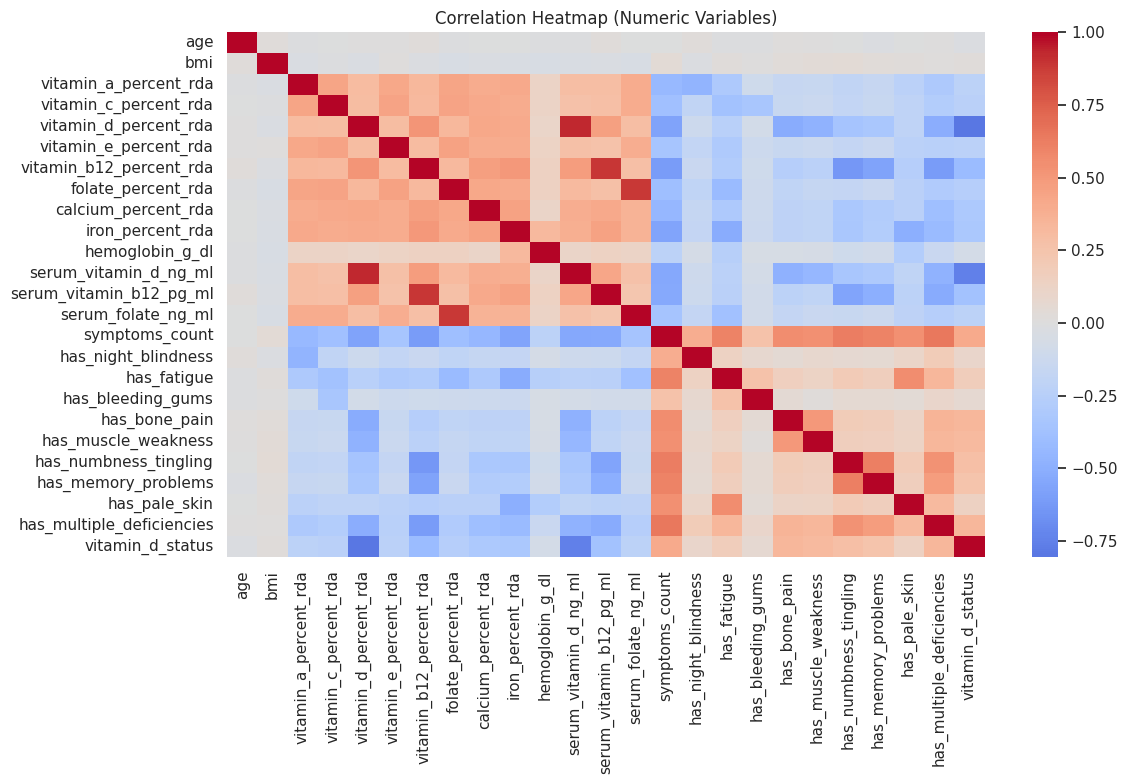

Business Interpretation: Strong positive/negative correlations may indicate potential risk drivers.



/tmp/ipykernel_430/3227508731.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=summary, x=group_col, y="Deficiency Rate (%)", palette="viridis")


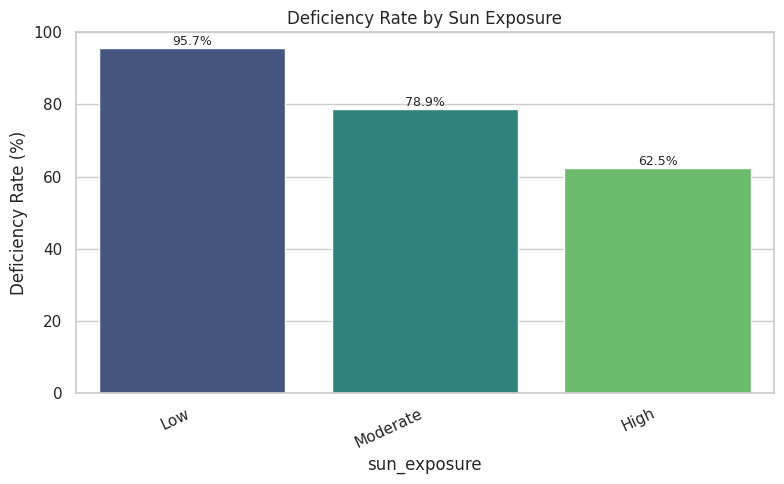

Business Interpretation: Highest-risk group in Sun Exposure is 'Low' (95.7%).



/tmp/ipykernel_430/3227508731.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=summary, x=group_col, y="Deficiency Rate (%)", palette="viridis")


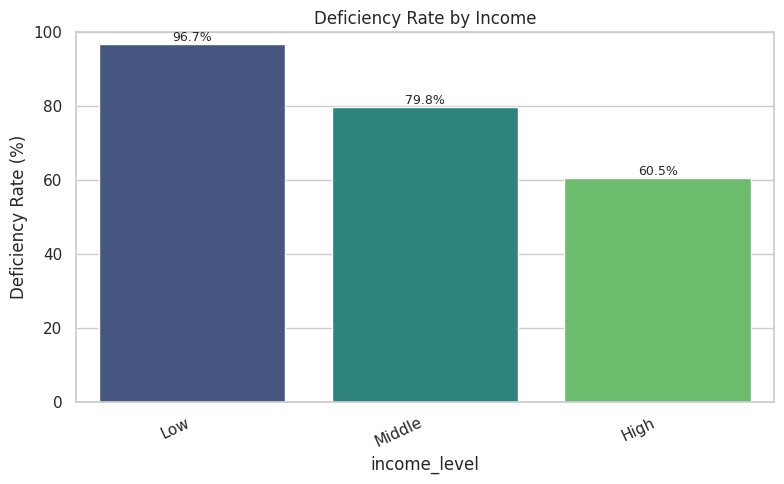

Business Interpretation: Highest-risk group in Income is 'Low' (96.7%).



/tmp/ipykernel_430/3227508731.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=summary, x=group_col, y="Deficiency Rate (%)", palette="viridis")


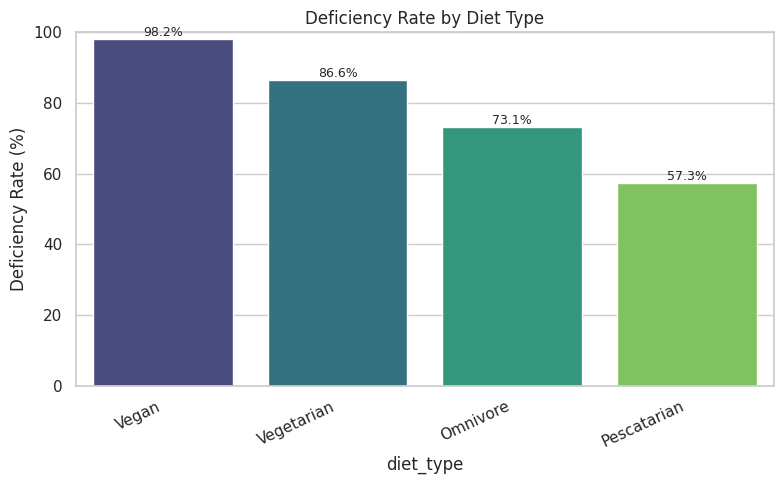

Business Interpretation: Highest-risk group in Diet Type is 'Vegan' (98.2%).

Income vs Deficiency (Row Percentage):


vitamin_d_status,Not Deficient (%),Deficient (%)
income_level,,
High,39.50,60.50
Low,3.25,96.75
Middle,20.23,79.77


Business Interpretation: Highest deficiency share appears in 'Low'.

Train shape: (3200, 14)
Test shape : (800, 14)

Logistic Regression Metrics
Accuracy : 0.8725
Precision: 0.9090
Recall   : 0.9320
F1 Score : 0.9203
ROC-AUC  : 0.9286


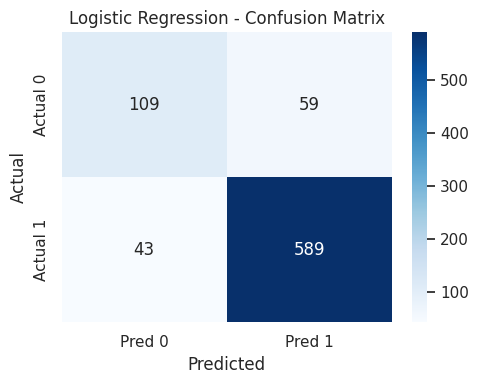

Logistic Regression 5-Fold CV Average Accuracy: 0.8797

Decision Tree Metrics
Accuracy : 0.8250
Precision: 0.8773
Recall   : 0.9051
F1 Score : 0.8910
ROC-AUC  : 0.8481


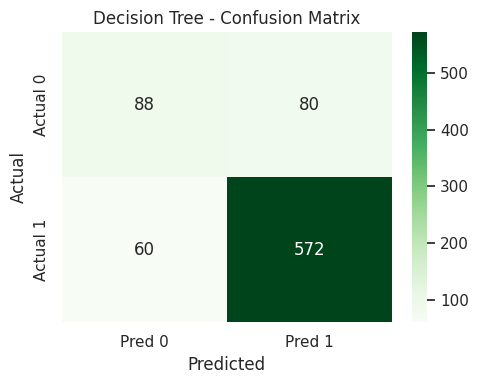

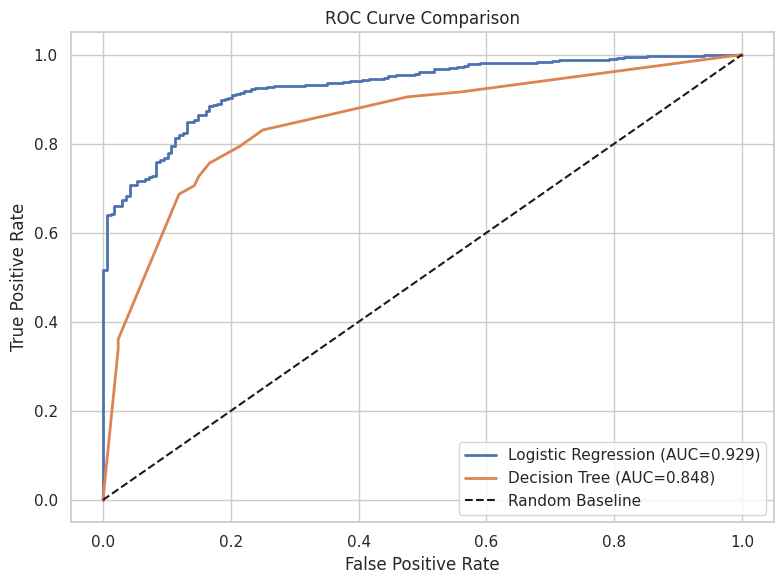

Decision Tree 5-Fold CV Average Accuracy: 0.8428

Model Comparison Table:
                         Model  Accuracy  Precision  Recall      F1  ROC-AUC
0          Logistic Regression    0.8725     0.9090  0.9320  0.9203   0.9286
1  Decision Tree (max_depth=4)    0.8250     0.8773  0.9051  0.8910   0.8481


/tmp/ipykernel_430/3227508731.py:299: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=log_top10.values, y=log_top10.index, orient="h", palette="Blues_r")


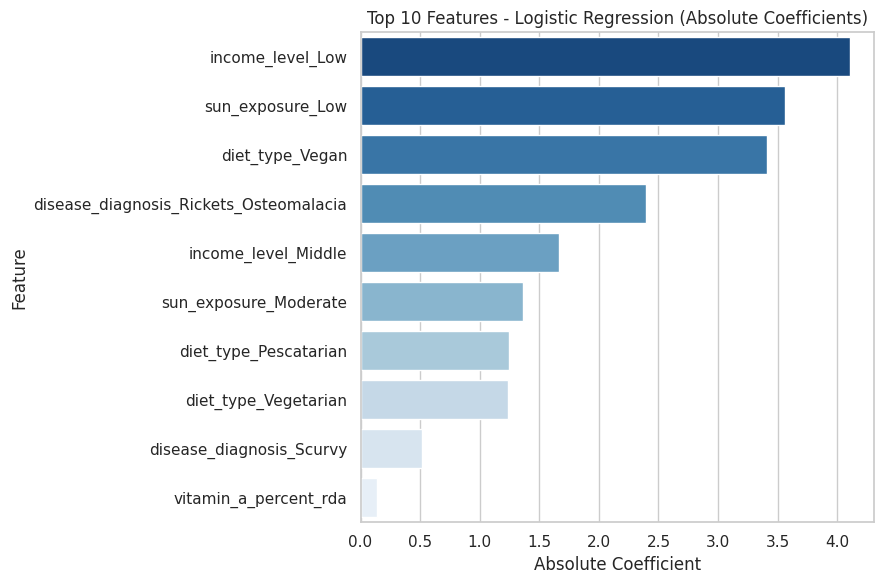

/tmp/ipykernel_430/3227508731.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tree_importance.values, y=tree_importance.index, orient="h", palette="Greens_r")


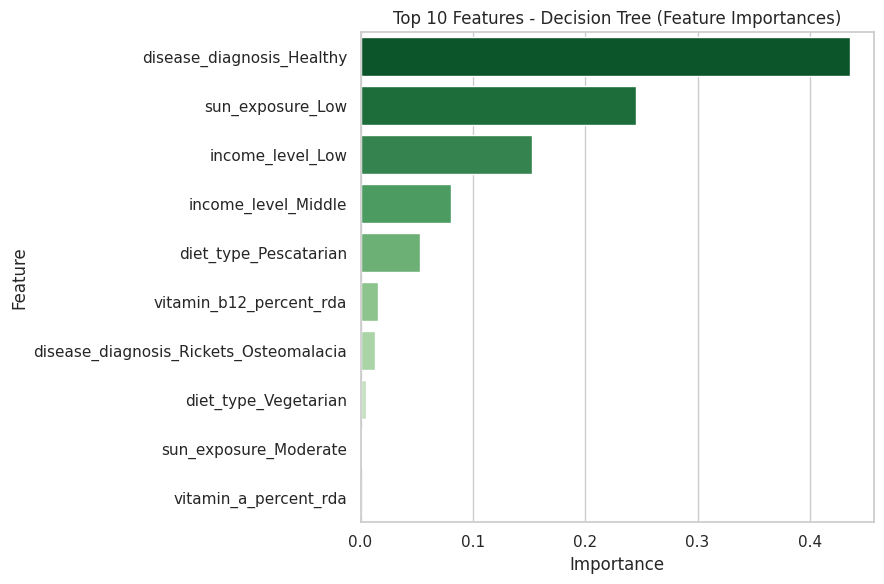


Risk Segmentation Summary:


,Risk_Segment,Count,Percentage
0,High Risk,596,74.50
1,Medium Risk,105,13.12
2,Low Risk,99,12.38



===== Business Insights =====
Top 3 Drivers of Deficiency:
1. income_level_Low
2. sun_exposure_Low
3. diet_type_Vegan

High-Risk Population (Logistic): 74.50%

Suggested Marketing Strategy:
Target High Risk with personalized bundles, Medium Risk with education + offers, Low Risk with reminder campaigns.

Business Value Based on Recall:
Recall is high: model captures most deficient individuals, enabling broad outreach.


In [4]:
# ============================================================
# AI Analytics Capstone: Vitamin D Deficiency Prediction
# Google Colab - Full End-to-End Code (Single Script)
# Dataset: "Dataset _vitamin_deficiency_disease.csv"
# ============================================================

# =========================
# 1) Import Libraries
# =========================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)

import ipywidgets as widgets
from IPython.display import display, clear_output

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


# =========================
# 2) Load Dataset from Google Drive
# =========================
drive.mount('/content/drive')

target_file = "Dataset _vitamin_deficiency_disease.csv"
base_dir = "/content/drive/MyDrive"

found_path = None
for root, dirs, files in os.walk(base_dir):
    if target_file in files:
        found_path = os.path.join(root, target_file)
        break

if found_path is None:
    raise FileNotFoundError(
        f"'{target_file}' not found in MyDrive. Check filename/folder."
    )

file_path = found_path
print("Using dataset:", file_path)

df = pd.read_csv(
    file_path,
    keep_default_na=False,
    na_values=["", " ", "NA", "N/A", "nan"]
)

print("\nFirst 5 rows:")
display(df.head())

print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")


# =========================
# Helper: Robust Column Resolver
# =========================
def normalize_col(name):
    return "".join(ch.lower() for ch in str(name) if ch.isalnum())

def get_col(df_columns, expected_name):
    if expected_name in df_columns:
        return expected_name
    expected_norm = normalize_col(expected_name)
    for c in df_columns:
        if normalize_col(c) == expected_norm:
            return c
    raise ValueError(f"Required column not found: {expected_name}")

col_vitd = get_col(df.columns, "Vitamin D Percent Rda")
col_sun = get_col(df.columns, "Sun Exposure")
try:
    col_income = get_col(df.columns, "Income")
except:
    col_income = get_col(df.columns, "income_level")
col_diet = get_col(df.columns, "Diet Type")
col_vita = get_col(df.columns, "Vitamin A Percent Rda")
col_b12 = get_col(df.columns, "Vitamin B12 Percent Rda")
col_vitc = get_col(df.columns, "Vitamin C Percent Rda")
col_disease = get_col(df.columns, "Disease Diagnosis")


# =========================
# 3) Feature Engineering
# =========================
df["vitamin_d_status"] = np.where(df[col_vitd] < 100, 1, 0)
deficiency_rate = df["vitamin_d_status"].mean() * 100
print(f"\nOverall Vitamin D Deficiency Rate: {deficiency_rate:.2f}%")


# =========================
# 4) Business-Focused EDA
# =========================
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Variables)")
plt.tight_layout()
plt.show()
print("Business Interpretation: Strong positive/negative correlations may indicate potential risk drivers.\n")

def deficiency_barplot(data, group_col, title_name):
    summary = (
        data.groupby(group_col)["vitamin_d_status"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .reset_index(name="Deficiency Rate (%)")
    )

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(data=summary, x=group_col, y="Deficiency Rate (%)", palette="viridis")
    plt.title(f"Deficiency Rate by {title_name}")
    plt.ylim(0, 100)
    plt.xticks(rotation=25, ha="right")

    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width()/2, h),
                    ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()
    print(f"Business Interpretation: Highest-risk group in {title_name} is '{summary.iloc[0,0]}' ({summary.iloc[0,1]:.1f}%).\n")

deficiency_barplot(df, col_sun, "Sun Exposure")
deficiency_barplot(df, col_income, "Income")
deficiency_barplot(df, col_diet, "Diet Type")

income_xtab = pd.crosstab(df[col_income], df["vitamin_d_status"], normalize="index") * 100
income_xtab = income_xtab.rename(columns={0: "Not Deficient (%)", 1: "Deficient (%)"}).round(2)
print("Income vs Deficiency (Row Percentage):")
display(income_xtab)
print(f"Business Interpretation: Highest deficiency share appears in '{income_xtab['Deficient (%)'].idxmax()}'.\n")


# =========================
# 5) Data Preparation
# =========================
feature_cols = [col_sun, col_income, col_diet, col_vita, col_b12, col_vitc, col_disease]
X = df[feature_cols].copy()
y = df["vitamin_d_status"].copy()

for c in X.columns:
    if X[c].dtype == "O":
        X[c] = X[c].fillna("Unknown")
    else:
        X[c] = X[c].fillna(X[c].median())

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = [col_vita, col_b12, col_vitc]
numeric_features = [f for f in numeric_features if f in X_train.columns]

X_train_log = X_train.copy()
X_test_log = X_test.copy()

scaler = StandardScaler()
X_train_log[numeric_features] = scaler.fit_transform(X_train_log[numeric_features])
X_test_log[numeric_features] = scaler.transform(X_test_log[numeric_features])

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


# =========================
# 6) Model 1 - Logistic Regression
# =========================
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_log, y_train)

y_pred_log = log_model.predict(X_test_log)
y_prob_log = log_model.predict_proba(X_test_log)[:, 1]

acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log, zero_division=0)
rec_log = recall_score(y_test, y_pred_log, zero_division=0)
f1_log = f1_score(y_test, y_pred_log, zero_division=0)
auc_log = roc_auc_score(y_test, y_prob_log)

print("\nLogistic Regression Metrics")
print(f"Accuracy : {acc_log:.4f}")
print(f"Precision: {prec_log:.4f}")
print(f"Recall   : {rec_log:.4f}")
print(f"F1 Score : {f1_log:.4f}")
print(f"ROC-AUC  : {auc_log:.4f}")

cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)

cv_log = cross_val_score(log_model, X_train_log, y_train, cv=5, scoring="accuracy")
print(f"Logistic Regression 5-Fold CV Average Accuracy: {cv_log.mean():.4f}")


# =========================
# 7) Model 2 - Decision Tree
# =========================
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

acc_tree = accuracy_score(y_test, y_pred_tree)
prec_tree = precision_score(y_test, y_pred_tree, zero_division=0)
rec_tree = recall_score(y_test, y_pred_tree, zero_division=0)
f1_tree = f1_score(y_test, y_pred_tree, zero_division=0)
auc_tree = roc_auc_score(y_test, y_prob_tree)

print("\nDecision Tree Metrics")
print(f"Accuracy : {acc_tree:.4f}")
print(f"Precision: {prec_tree:.4f}")
print(f"Recall   : {rec_tree:.4f}")
print(f"F1 Score : {f1_tree:.4f}")
print(f"ROC-AUC  : {auc_tree:.4f}")

cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC={auc_log:.3f})", linewidth=2)
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC={auc_tree:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random Baseline")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

cv_tree = cross_val_score(tree_model, X_train, y_train, cv=5, scoring="accuracy")
print(f"Decision Tree 5-Fold CV Average Accuracy: {cv_tree.mean():.4f}")


# =========================
# 8) Model Comparison
# =========================
comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree (max_depth=4)"],
    "Accuracy": [acc_log, acc_tree],
    "Precision": [prec_log, prec_tree],
    "Recall": [rec_log, rec_tree],
    "F1": [f1_log, f1_tree],
    "ROC-AUC": [auc_log, auc_tree]
})

print("\nModel Comparison Table:")
print(comparison_table.round(4))


# =========================
# 9) Feature Importance Analysis
# =========================
log_coef = pd.Series(log_model.coef_[0], index=X_train_log.columns)
log_top10 = log_coef.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=log_top10.values, y=log_top10.index, orient="h", palette="Blues_r")
plt.title("Top 10 Features - Logistic Regression (Absolute Coefficients)")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

tree_importance = pd.Series(tree_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=tree_importance.values, y=tree_importance.index, orient="h", palette="Greens_r")
plt.title("Top 10 Features - Decision Tree (Feature Importances)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# =========================
# 10) Probability-Based Risk Segmentation
# =========================
risk_df = pd.DataFrame({
    "Actual_Status": y_test.values,
    "Deficiency_Probability": y_prob_log
})

def assign_risk(prob):
    if prob >= 0.70:
        return "High Risk"
    elif prob >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df["Risk_Segment"] = risk_df["Deficiency_Probability"].apply(assign_risk)

risk_summary = risk_df["Risk_Segment"].value_counts().rename_axis("Risk_Segment").reset_index(name="Count")
risk_summary["Percentage"] = (risk_summary["Count"] / risk_summary["Count"].sum() * 100).round(2)
order = ["High Risk", "Medium Risk", "Low Risk"]
risk_summary["Risk_Segment"] = pd.Categorical(risk_summary["Risk_Segment"], categories=order, ordered=True)
risk_summary = risk_summary.sort_values("Risk_Segment").reset_index(drop=True)

print("\nRisk Segmentation Summary:")
display(risk_summary)


# =========================
# 11) Business Insight Section
# =========================
top3_drivers = log_coef.abs().sort_values(ascending=False).head(3).index.tolist()
high_risk_pct = risk_summary.loc[risk_summary["Risk_Segment"] == "High Risk", "Percentage"]
high_risk_pct = float(high_risk_pct.iloc[0]) if len(high_risk_pct) > 0 else 0.0

if rec_log >= 0.75:
    recall_message = "Recall is high: model captures most deficient individuals, enabling broad outreach."
else:
    recall_message = "Recall is moderate/low: consider lower threshold to reduce missed deficient individuals."

print("\n===== Business Insights =====")
print("Top 3 Drivers of Deficiency:")
for i, d in enumerate(top3_drivers, 1):
    print(f"{i}. {d}")

print(f"\nHigh-Risk Population (Logistic): {high_risk_pct:.2f}%")
print("\nSuggested Marketing Strategy:")
print("Target High Risk with personalized bundles, Medium Risk with education + offers, Low Risk with reminder campaigns.")
print("\nBusiness Value Based on Recall:")
print(recall_message)


# =========================
# 12) Clickable Multi-Patient Predictor
# =========================
def preprocess_for_logistic_prediction(raw_df, training_columns, scaler, numeric_features):
    X_new = raw_df.copy()

    for c in X_new.columns:
        if X_new[c].dtype == "O":
            X_new[c] = X_new[c].fillna("Unknown")
        else:
            X_new[c] = X_new[c].fillna(X_new[c].median())

    X_new = pd.get_dummies(X_new, drop_first=True)

    for c in training_columns:
        if c not in X_new.columns:
            X_new[c] = 0

    X_new = X_new[training_columns]

    cols_to_scale = [c for c in numeric_features if c in X_new.columns]
    if cols_to_scale:
        X_new[cols_to_scale] = scaler.transform(X_new[cols_to_scale])

    return X_new

def launch_clickable_patient_form_multi():
    training_columns = X_train.columns.tolist()
    local_numeric_features = [col_vita, col_b12, col_vitc]

    sun_options = sorted(df[col_sun].dropna().astype(str).unique().tolist())
    income_options = sorted(df[col_income].dropna().astype(str).unique().tolist())
    diet_options = sorted(df[col_diet].dropna().astype(str).unique().tolist())
    disease_options = sorted(df[col_disease].dropna().astype(str).unique().tolist())

    vit_options = ["<70", "70-99", "100-129", "130+"]
    vit_map = {"<70": 60.0, "70-99": 85.0, "100-129": 110.0, "130+": 140.0}

    questions = [
        ("Sun Exposure", sun_options, col_sun),
        ("Income", income_options, col_income),
        ("Diet Type", diet_options, col_diet),
        ("Vitamin A Percent Rda", vit_options, col_vita),
        ("Vitamin B12 Percent Rda", vit_options, col_b12),
        ("Vitamin C Percent Rda", vit_options, col_vitc),
        ("Disease Diagnosis", disease_options, col_disease),
    ]

    state = {"i": 0, "answers": {}}

    title = widgets.HTML("<h4>Patient Vitamin D Deficiency Screening</h4>")
    q_label = widgets.HTML()
    choice = widgets.RadioButtons(options=[], description="Options:")
    next_btn = widgets.Button(description="Next", button_style="primary")
    new_btn = widgets.Button(description="New Patient", button_style="info")
    out = widgets.Output()

    def render():
        i = state["i"]
        q, opts, _ = questions[i]
        q_label.value = f"<b>Question {i+1} of {len(questions)}:</b> {q}"
        choice.options = opts
        choice.value = opts[0] if opts else None
        next_btn.description = "Predict" if i == len(questions)-1 else "Next"

    def reset_form(_=None):
        state["i"] = 0
        state["answers"] = {}
        choice.layout.display = "block"
        next_btn.layout.display = "inline-flex"
        with out:
            clear_output()
        render()

    def on_next(_):
        i = state["i"]
        _, _, key = questions[i]
        state["answers"][key] = choice.value

        if i < len(questions)-1:
            state["i"] += 1
            render()
            return

        a = state["answers"]
        patient_df = pd.DataFrame([{
            col_sun: a[col_sun],
            col_income: a[col_income],
            col_diet: a[col_diet],
            col_vita: vit_map[a[col_vita]],
            col_b12: vit_map[a[col_b12]],
            col_vitc: vit_map[a[col_vitc]],
            col_disease: a[col_disease],
        }])

        X_new = preprocess_for_logistic_prediction(
            patient_df, training_columns, scaler, local_numeric_features
        )

        pred_class = int(log_model.predict(X_new)[0])
        pred_prob = float(log_model.predict_proba(X_new)[:, 1][0])

        risk = "High" if pred_prob >= 0.70 else ("Medium" if pred_prob >= 0.40 else "Low")
        label = "Deficient" if pred_class == 1 else "Not Deficient"

        with out:
            clear_output()
            print("Prediction:", label)
            print(f"Probability of Deficiency: {pred_prob*100:.2f}%")
            print("Risk Category:", risk)
            print("\nClick 'New Patient' to predict another patient.")

        q_label.value = "<b>Completed.</b>"
        choice.layout.display = "none"
        next_btn.layout.display = "none"

    next_btn.on_click(on_next)
    new_btn.on_click(reset_form)

    render()
    display(widgets.VBox([title, q_label, choice, widgets.HBox([next_btn, new_btn]), out]))

# Run interactive predictor:
launch_clickable_patient_form_multi()
